In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Color palette for consistent visualization
COLORS = {
    'multinomial': '#2ecc71',  # Green
    'ovr': '#3498db',          # Blue
    'ovo': '#e74c3c',          # Red
    'full': '#9b59b6',         # Purple
    'left': '#f39c12',         # Orange
    'right': '#1abc9c'         # Teal
}

print("✓ Imports and configuration complete")

✓ Imports and configuration complete


In [2]:
# Base directory for results
BASE_DIR = Path("/home/sjoon/projects/brain_connectivity_classifier/data/results")
# Define paths for each model's CV results
RESULTS_PATHS = {
    # Full brain models (232 regions)
    ('full', 'multinomial'): BASE_DIR / "full_connectivity_analysis/multinomial",
    ('full', 'ovr'): BASE_DIR / "full_connectivity_analysis/ovr",
    ('full', 'ovo'): BASE_DIR / "full_connectivity_analysis/ovo",
    
    # Left hemisphere models (116 regions)
    ('left', 'multinomial'): BASE_DIR / "hemisphere_analysis/left_hemisphere/multinomial",
    ('left', 'ovr'): BASE_DIR / "hemisphere_analysis/left_hemisphere/ovr",
    ('left', 'ovo'): BASE_DIR / "hemisphere_analysis/left_hemisphere/ovo",
    
    # Right hemisphere models (116 regions)
    ('right', 'multinomial'): BASE_DIR / "hemisphere_analysis/right_hemisphere/multinomial",
    ('right', 'ovr'): BASE_DIR / "hemisphere_analysis/right_hemisphere/ovr",
    ('right', 'ovo'): BASE_DIR / "hemisphere_analysis/right_hemisphere/ovo",
}

# Task testing results paths (separate from CV results)
TASK_PATHS = {
    # Full brain - each strategy has its own task_testing directory
    ('full', 'multinomial'): BASE_DIR / "full_connectivity_analysis/task_testing",
    ('full', 'ovr'): BASE_DIR / "full_connectivity_analysis/task_testing_ovr",
    ('full', 'ovo'): BASE_DIR / "full_connectivity_analysis/task_testing_ovo",
    
    # Hemispheres - single task_testing directory per hemisphere (likely OvO based on your logs)
    ('left', 'multinomial'): BASE_DIR / "hemisphere_analysis/left_hemisphere/task_testing_multinomial",
    ('left', 'ovr'): BASE_DIR / "hemisphere_analysis/left_hemisphere/task_testing_ovr",
    ('left', 'ovo'): BASE_DIR / "hemisphere_analysis/left_hemisphere/task_testing_ovo",
    
    ('right', 'multinomial'): BASE_DIR / "hemisphere_analysis/right_hemisphere/task_testing_multinomial",
    ('right', 'ovr'): BASE_DIR / "hemisphere_analysis/right_hemisphere/task_testing_ovr",
    ('right', 'ovo'): BASE_DIR / "hemisphere_analysis/right_hemisphere/task_testing_ovo",
}

# Output directory for analysis results
OUTPUT_DIR = Path("reports/performance_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")
print("\nChecking CV results directories...")
for key, path in RESULTS_PATHS.items():
    status = "✓" if path.exists() else "✗"
    print(f"  {status} {key[0]:6} {key[1]:12} : {path}")

print("\nChecking Task testing directories...")
for key, path in TASK_PATHS.items():
    status = "✓" if path.exists() else "✗"
    print(f"  {status} {key[0]:6} {key[1]:12} : {path}")

Output directory: reports/performance_comparison

Checking CV results directories...
  ✓ full   multinomial  : /home/sjoon/projects/brain_connectivity_classifier/data/results/full_connectivity_analysis/multinomial
  ✓ full   ovr          : /home/sjoon/projects/brain_connectivity_classifier/data/results/full_connectivity_analysis/ovr
  ✓ full   ovo          : /home/sjoon/projects/brain_connectivity_classifier/data/results/full_connectivity_analysis/ovo
  ✓ left   multinomial  : /home/sjoon/projects/brain_connectivity_classifier/data/results/hemisphere_analysis/left_hemisphere/multinomial
  ✓ left   ovr          : /home/sjoon/projects/brain_connectivity_classifier/data/results/hemisphere_analysis/left_hemisphere/ovr
  ✓ left   ovo          : /home/sjoon/projects/brain_connectivity_classifier/data/results/hemisphere_analysis/left_hemisphere/ovo
  ✓ right  multinomial  : /home/sjoon/projects/brain_connectivity_classifier/data/results/hemisphere_analysis/right_hemisphere/multinomial
  ✓ rig

In [3]:
def load_model_results(results_dir: Path, task_dir: Path = None) -> Dict:
    """
    Load all results for a single model from its directory.
    
    Parameters:
        results_dir: Path to CV results (overall_metrics.json, etc.)
        task_dir: Path to task testing results (task_testing_summary.json)
    
    Returns dict with:
        - overall_metrics: accuracy, balanced_accuracy, etc.
        - task_metrics: task testing results (if available)
        - per_region_metrics: DataFrame of per-region accuracy
        - network_metrics: DataFrame of network-level accuracy
    """
    results = {}
    
    # Load overall metrics (CV results)
    metrics_file = results_dir / "overall_metrics.json"
    if metrics_file.exists():
        with open(metrics_file, 'r') as f:
            results['overall_metrics'] = json.load(f)
    else:
        print(f"  ⚠ Missing: {metrics_file}")
        results['overall_metrics'] = {}
    
    # Load task testing results from task_dir
    if task_dir is not None and task_dir.exists():
        task_file = task_dir / "task_testing_summary.json"
        if task_file.exists():
            with open(task_file, 'r') as f:
                results['task_metrics'] = json.load(f)
        else:
            print(f"  ⚠ Missing task file: {task_file}")
            results['task_metrics'] = {}
    else:
        results['task_metrics'] = {}
    
    # Load per-region metrics (CV)
    per_region_file = results_dir / "per_region_metrics.csv"
    if per_region_file.exists():
        results['per_region_metrics'] = pd.read_csv(per_region_file)
    else:
        results['per_region_metrics'] = pd.DataFrame()
    
    # Load network metrics (CV)
    network_file = results_dir / "network_metrics.csv"
    if network_file.exists():
        results['network_metrics'] = pd.read_csv(network_file)
    else:
        results['network_metrics'] = pd.DataFrame()
    
    # Load task per-region metrics if available
    if task_dir is not None and task_dir.exists():
        task_per_region = task_dir / "task_per_region_metrics.csv"
        if task_per_region.exists():
            results['task_per_region_metrics'] = pd.read_csv(task_per_region)
        else:
            results['task_per_region_metrics'] = pd.DataFrame()
        
        task_network = task_dir / "task_network_metrics.csv"
        if task_network.exists():
            results['task_network_metrics'] = pd.read_csv(task_network)
        else:
            results['task_network_metrics'] = pd.DataFrame()
    
    return results

def load_all_results() -> Dict[Tuple[str, str], Dict]:
    """Load results from all 9 models."""
    all_results = {}
    
    print("Loading results from all models...")
    for (data_type, strategy), cv_path in RESULTS_PATHS.items():
        task_path = TASK_PATHS.get((data_type, strategy))
        
        if cv_path.exists():
            print(f"  Loading {data_type} - {strategy}...")
            all_results[(data_type, strategy)] = load_model_results(cv_path, task_path)
        else:
            print(f"  ⚠ Skipping {data_type} - {strategy} (CV directory not found)")
            all_results[(data_type, strategy)] = None
    
    # Count successful loads
    n_loaded = sum(1 for v in all_results.values() if v is not None)
    print(f"\n✓ Loaded {n_loaded}/9 models")
    
    return all_results

# Load all results
ALL_RESULTS = load_all_results()

Loading results from all models...
  Loading full - multinomial...
  Loading full - ovr...
  Loading full - ovo...
  Loading left - multinomial...
  Loading left - ovr...
  Loading left - ovo...
  Loading right - multinomial...
  Loading right - ovr...
  Loading right - ovo...

✓ Loaded 9/9 models


In [4]:
def create_summary_table(all_results: Dict) -> pd.DataFrame:
    """
    Create a comprehensive summary table of all model performance metrics.
    """
    rows = []
    
    for (data_type, strategy), results in all_results.items():
        if results is None:
            continue
        
        row = {
            'data_type': data_type,
            'strategy': strategy,
            'n_regions': 232 if data_type == 'full' else 116,
        }
        
        # CV metrics
        om = results.get('overall_metrics', {})
        row['cv_accuracy'] = om.get('accuracy', np.nan)
        row['cv_balanced_accuracy'] = om.get('balanced_accuracy', np.nan)
        row['cv_top5_accuracy'] = om.get('top_5_accuracy', np.nan)
        row['cv_f1_score'] = om.get('f1_score', np.nan)
        
        # Hyperparameters
        hp = om.get('best_hyperparameters', {})
        row['best_C'] = hp.get('C', np.nan)
        row['solver'] = hp.get('solver', 'N/A')
        
        # Task metrics - handle different key names in the JSON
        tm = results.get('task_metrics', {})
        # Try different possible key names
        row['task_accuracy'] = (
            tm.get('task_test_accuracy') or 
            tm.get('task_accuracy') or 
            tm.get('accuracy', np.nan)
        )
        row['rest_train_accuracy'] = (
            tm.get('rest_train_accuracy') or 
            tm.get('train_accuracy', np.nan)
        )
        
        # Calculate accuracy drop (CV accuracy - Task accuracy)
        if not np.isnan(row['cv_accuracy']) and row['task_accuracy'] is not None and not np.isnan(row['task_accuracy']):
            row['accuracy_drop'] = row['cv_accuracy'] - row['task_accuracy']
            row['accuracy_drop_pct'] = (row['accuracy_drop'] / row['cv_accuracy']) * 100
        else:
            row['accuracy_drop'] = np.nan
            row['accuracy_drop_pct'] = np.nan
        
        rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Sort by data_type and strategy for consistent ordering
    order_data = {'full': 0, 'left': 1, 'right': 2}
    order_strategy = {'multinomial': 0, 'ovr': 1, 'ovo': 2}
    df['sort_data'] = df['data_type'].map(order_data)
    df['sort_strategy'] = df['strategy'].map(order_strategy)
    df = df.sort_values(['sort_data', 'sort_strategy']).drop(columns=['sort_data', 'sort_strategy'])
    df = df.reset_index(drop=True)
    
    return df

# Create summary table
summary_df = create_summary_table(ALL_RESULTS)

print("\n" + "="*80)
print("PERFORMANCE SUMMARY TABLE")
print("="*80)
display_cols = ['data_type', 'strategy', 'n_regions', 'cv_accuracy', 'task_accuracy', 
                'accuracy_drop', 'accuracy_drop_pct']
print(summary_df[display_cols].to_string(index=False))

# Check for duplicate task results (hemispheres sharing same task_testing dir)
print("\n" + "-"*80)
print("Note: Checking task testing data sources...")
for data_type in ['full', 'left', 'right']:
    subset = summary_df[summary_df['data_type'] == data_type]
    unique_task_acc = subset['task_accuracy'].dropna().unique()
    if len(unique_task_acc) == 1 and len(subset) > 1:
        print(f"  ⚠ {data_type.upper()}: All strategies share same task accuracy ({unique_task_acc[0]:.4f})")
        print(f"      → Task testing may have been run with only one model")
    else:
        print(f"  ✓ {data_type.upper()}: Task accuracies differ across strategies")
# Save to CSV
summary_df.to_csv(OUTPUT_DIR / "performance_summary.csv", index=False)

# Save summary df



PERFORMANCE SUMMARY TABLE
data_type    strategy  n_regions  cv_accuracy  task_accuracy  accuracy_drop  accuracy_drop_pct
     full multinomial        232     0.924126       0.892392       0.031734           3.433961
     full         ovr        232     0.931708       0.896336       0.035372           3.796444
     full         ovo        232     0.868785       0.830496       0.038289           4.407185
     left multinomial        116     0.918180       0.869310       0.048870           5.322491
     left         ovr        116     0.922645       0.875690       0.046955           5.089180
     left         ovo        116     0.881427       0.835862       0.045565           5.169454
    right multinomial        116     0.913562       0.863060       0.050502           5.528014
    right         ovr        116     0.920836       0.871034       0.049801           5.408284
    right         ovo        116     0.875269       0.823578       0.051692           5.905817

----------------------

✓ Saved: reports/performance_comparison/fig1_strategy_comparison.png


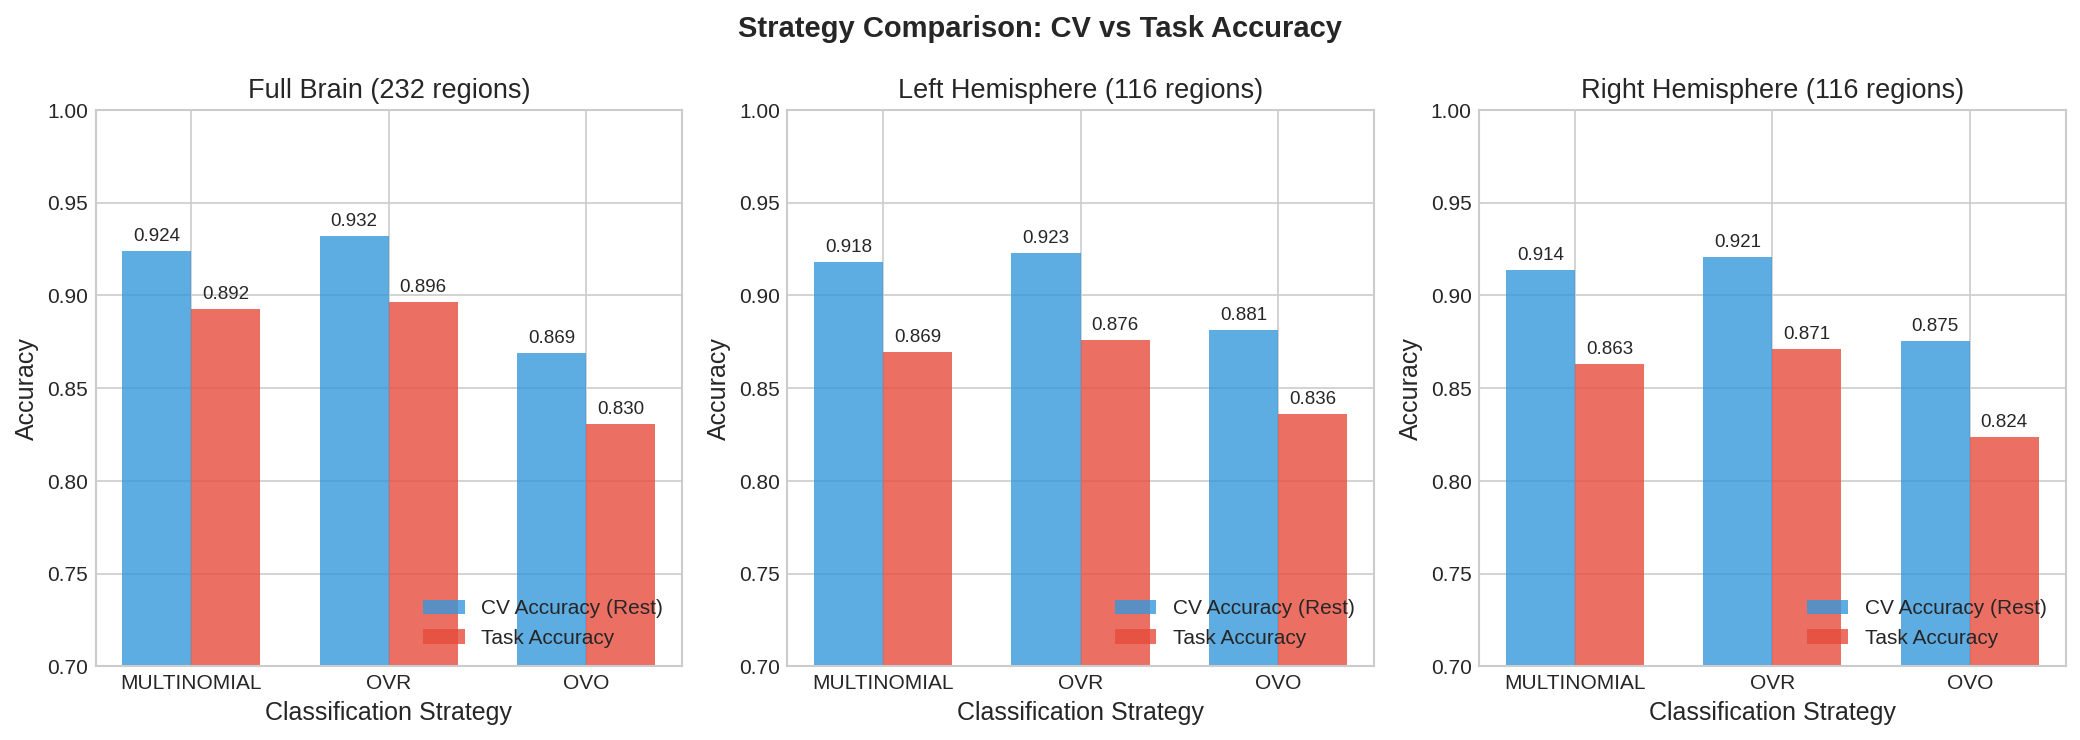

In [5]:
def plot_strategy_comparison(summary_df: pd.DataFrame, save_path: Optional[Path] = None):
    """
    Bar plot comparing classification strategies within each data type.
    Shows both CV accuracy and Task accuracy side by side.
    """
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    
    data_types = ['full', 'left', 'right']
    titles = ['Full Brain (232 regions)', 'Left Hemisphere (116 regions)', 'Right Hemisphere (116 regions)']
    
    for ax, data_type, title in zip(axes, data_types, titles):
        df_subset = summary_df[summary_df['data_type'] == data_type]
        
        if df_subset.empty:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title)
            continue
        
        x = np.arange(len(df_subset))
        width = 0.35
        
        # Plot CV accuracy
        bars1 = ax.bar(x - width/2, df_subset['cv_accuracy'], width, 
                       label='CV Accuracy (Rest)', color='#3498db', alpha=0.8)
        
        # Plot Task accuracy
        bars2 = ax.bar(x + width/2, df_subset['task_accuracy'], width,
                       label='Task Accuracy', color='#e74c3c', alpha=0.8)
        
        # Add value labels
        for bar in bars1:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.3f}',
                           xy=(bar.get_x() + bar.get_width()/2, height),
                           xytext=(0, 3), textcoords="offset points",
                           ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.3f}',
                           xy=(bar.get_x() + bar.get_width()/2, height),
                           xytext=(0, 3), textcoords="offset points",
                           ha='center', va='bottom', fontsize=9)
        
        ax.set_xlabel('Classification Strategy')
        ax.set_ylabel('Accuracy')
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels([s.upper() for s in df_subset['strategy']])
        ax.set_ylim(0.7, 1.0)
        ax.legend(loc='lower right')
        ax.axhline(y=1/232 if data_type == 'full' else 1/116, 
                   color='gray', linestyle='--', alpha=0.5, label='Chance')
    
    plt.suptitle('Strategy Comparison: CV vs Task Accuracy', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"✓ Saved: {save_path}")
    
    plt.show()

# Create the plot
plot_strategy_comparison(summary_df, OUTPUT_DIR / "fig1_strategy_comparison.png")

✓ Saved: reports/performance_comparison/fig2_data_type_comparison.png


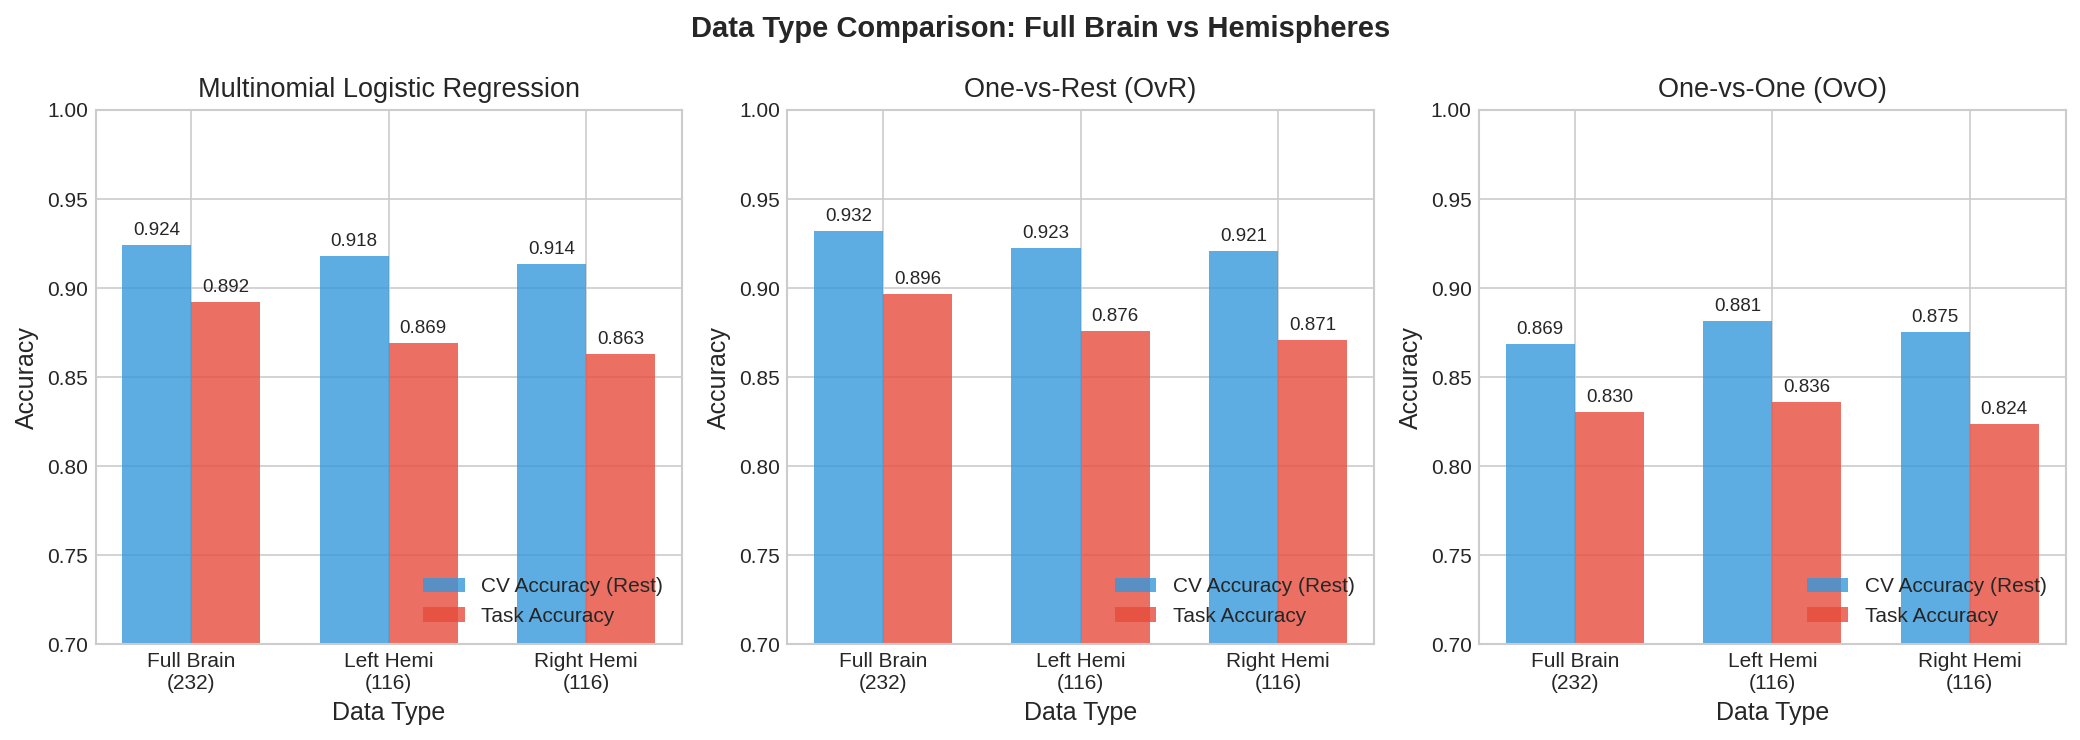

In [6]:
# Compare Full Brain vs Left Hemisphere vs Right Hemisphere for each strategy.

def plot_data_type_comparison(summary_df: pd.DataFrame, save_path: Optional[Path] = None):
    """
    Bar plot comparing data types (Full, Left, Right) within each strategy.
    """
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    
    strategies = ['multinomial', 'ovr', 'ovo']
    titles = ['Multinomial Logistic Regression', 'One-vs-Rest (OvR)', 'One-vs-One (OvO)']
    
    for ax, strategy, title in zip(axes, strategies, titles):
        df_subset = summary_df[summary_df['strategy'] == strategy]
        
        if df_subset.empty:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title)
            continue
        
        x = np.arange(len(df_subset))
        width = 0.35
        
        colors_data = [COLORS['full'], COLORS['left'], COLORS['right']]
        
        # Plot CV accuracy
        bars1 = ax.bar(x - width/2, df_subset['cv_accuracy'], width,
                       label='CV Accuracy (Rest)', color='#3498db', alpha=0.8)
        
        # Plot Task accuracy
        bars2 = ax.bar(x + width/2, df_subset['task_accuracy'], width,
                       label='Task Accuracy', color='#e74c3c', alpha=0.8)
        
        # Add value labels
        for bar in bars1:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.3f}',
                           xy=(bar.get_x() + bar.get_width()/2, height),
                           xytext=(0, 3), textcoords="offset points",
                           ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.3f}',
                           xy=(bar.get_x() + bar.get_width()/2, height),
                           xytext=(0, 3), textcoords="offset points",
                           ha='center', va='bottom', fontsize=9)
        
        ax.set_xlabel('Data Type')
        ax.set_ylabel('Accuracy')
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(['Full Brain\n(232)', 'Left Hemi\n(116)', 'Right Hemi\n(116)'])
        ax.set_ylim(0.7, 1.0)
        ax.legend(loc='lower right')
    
    plt.suptitle('Data Type Comparison: Full Brain vs Hemispheres', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"✓ Saved: {save_path}")
    
    plt.show()

# Create the plot
plot_data_type_comparison(summary_df, OUTPUT_DIR / "fig2_data_type_comparison.png")

✓ Saved: reports/performance_comparison/fig3_generalization_gap.png


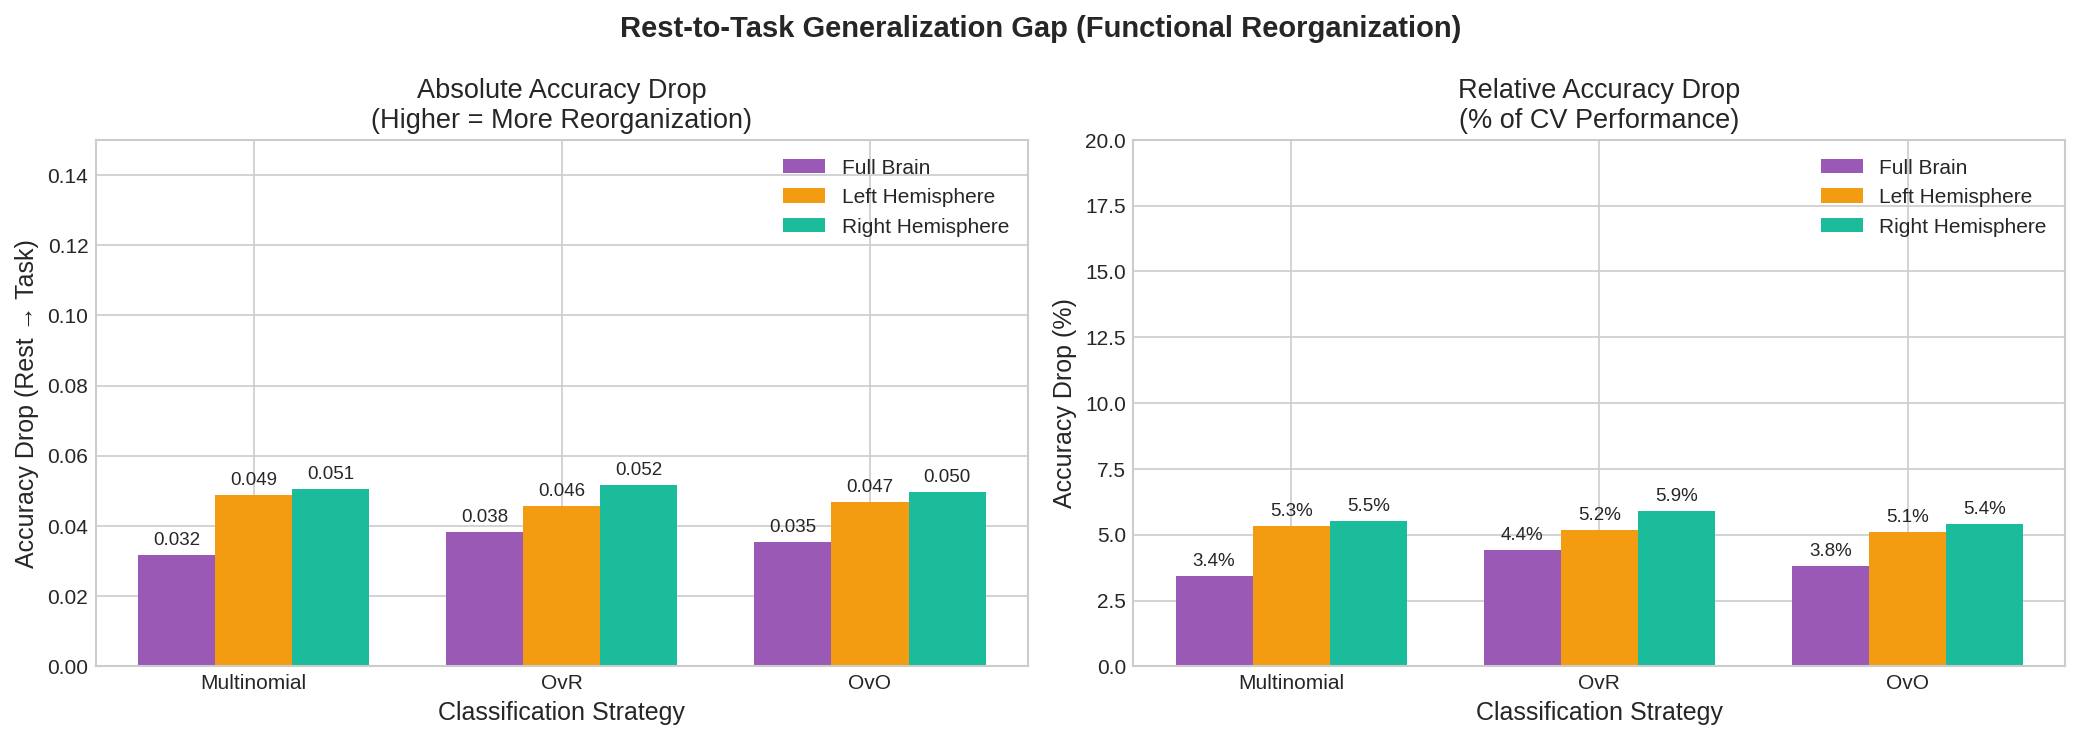

In [7]:
# Comparison 3 - Rest-to-Task Generalization Gap
def plot_generalization_gap(summary_df: pd.DataFrame, save_path: Optional[Path] = None):
    """
    Visualize the accuracy drop from rest to task for all models.
    This represents the magnitude of functional reorganization.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Plot 1: Accuracy Drop (absolute) ---
    ax1 = axes[0]
    
    # Prepare data for grouped bar chart
    df_pivot = summary_df.pivot(index='strategy', columns='data_type', values='accuracy_drop')
    df_pivot = df_pivot[['full', 'left', 'right']]  # Reorder columns
    
    x = np.arange(len(df_pivot.index))
    width = 0.25
    
    bars1 = ax1.bar(x - width, df_pivot['full'], width, label='Full Brain', color=COLORS['full'])
    bars2 = ax1.bar(x, df_pivot['left'], width, label='Left Hemisphere', color=COLORS['left'])
    bars3 = ax1.bar(x + width, df_pivot['right'], width, label='Right Hemisphere', color=COLORS['right'])
    
    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                ax1.annotate(f'{height:.3f}',
                           xy=(bar.get_x() + bar.get_width()/2, height),
                           xytext=(0, 3), textcoords="offset points",
                           ha='center', va='bottom', fontsize=9)
    
    ax1.set_xlabel('Classification Strategy')
    ax1.set_ylabel('Accuracy Drop (Rest → Task)')
    ax1.set_title('Absolute Accuracy Drop\n(Higher = More Reorganization)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(['Multinomial', 'OvR', 'OvO'])
    ax1.legend()
    ax1.set_ylim(0, max(summary_df['accuracy_drop'].max() * 1.3, 0.15))
    
    # --- Plot 2: Accuracy Drop (percentage) ---
    ax2 = axes[1]
    
    df_pivot_pct = summary_df.pivot(index='strategy', columns='data_type', values='accuracy_drop_pct')
    df_pivot_pct = df_pivot_pct[['full', 'left', 'right']]
    
    bars1 = ax2.bar(x - width, df_pivot_pct['full'], width, label='Full Brain', color=COLORS['full'])
    bars2 = ax2.bar(x, df_pivot_pct['left'], width, label='Left Hemisphere', color=COLORS['left'])
    bars3 = ax2.bar(x + width, df_pivot_pct['right'], width, label='Right Hemisphere', color=COLORS['right'])
    
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                ax2.annotate(f'{height:.1f}%',
                           xy=(bar.get_x() + bar.get_width()/2, height),
                           xytext=(0, 3), textcoords="offset points",
                           ha='center', va='bottom', fontsize=9)
    
    ax2.set_xlabel('Classification Strategy')
    ax2.set_ylabel('Accuracy Drop (%)')
    ax2.set_title('Relative Accuracy Drop\n(% of CV Performance)')
    ax2.set_xticks(x)
    ax2.set_xticklabels(['Multinomial', 'OvR', 'OvO'])
    ax2.legend()
    ax2.set_ylim(0, max(summary_df['accuracy_drop_pct'].max() * 1.3, 20))
    
    plt.suptitle('Rest-to-Task Generalization Gap (Functional Reorganization)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"✓ Saved: {save_path}")
    
    plt.show()

# Create the plot
plot_generalization_gap(summary_df, OUTPUT_DIR / "fig3_generalization_gap.png")

✓ Saved: reports/performance_comparison/fig4_performance_heatmap.png


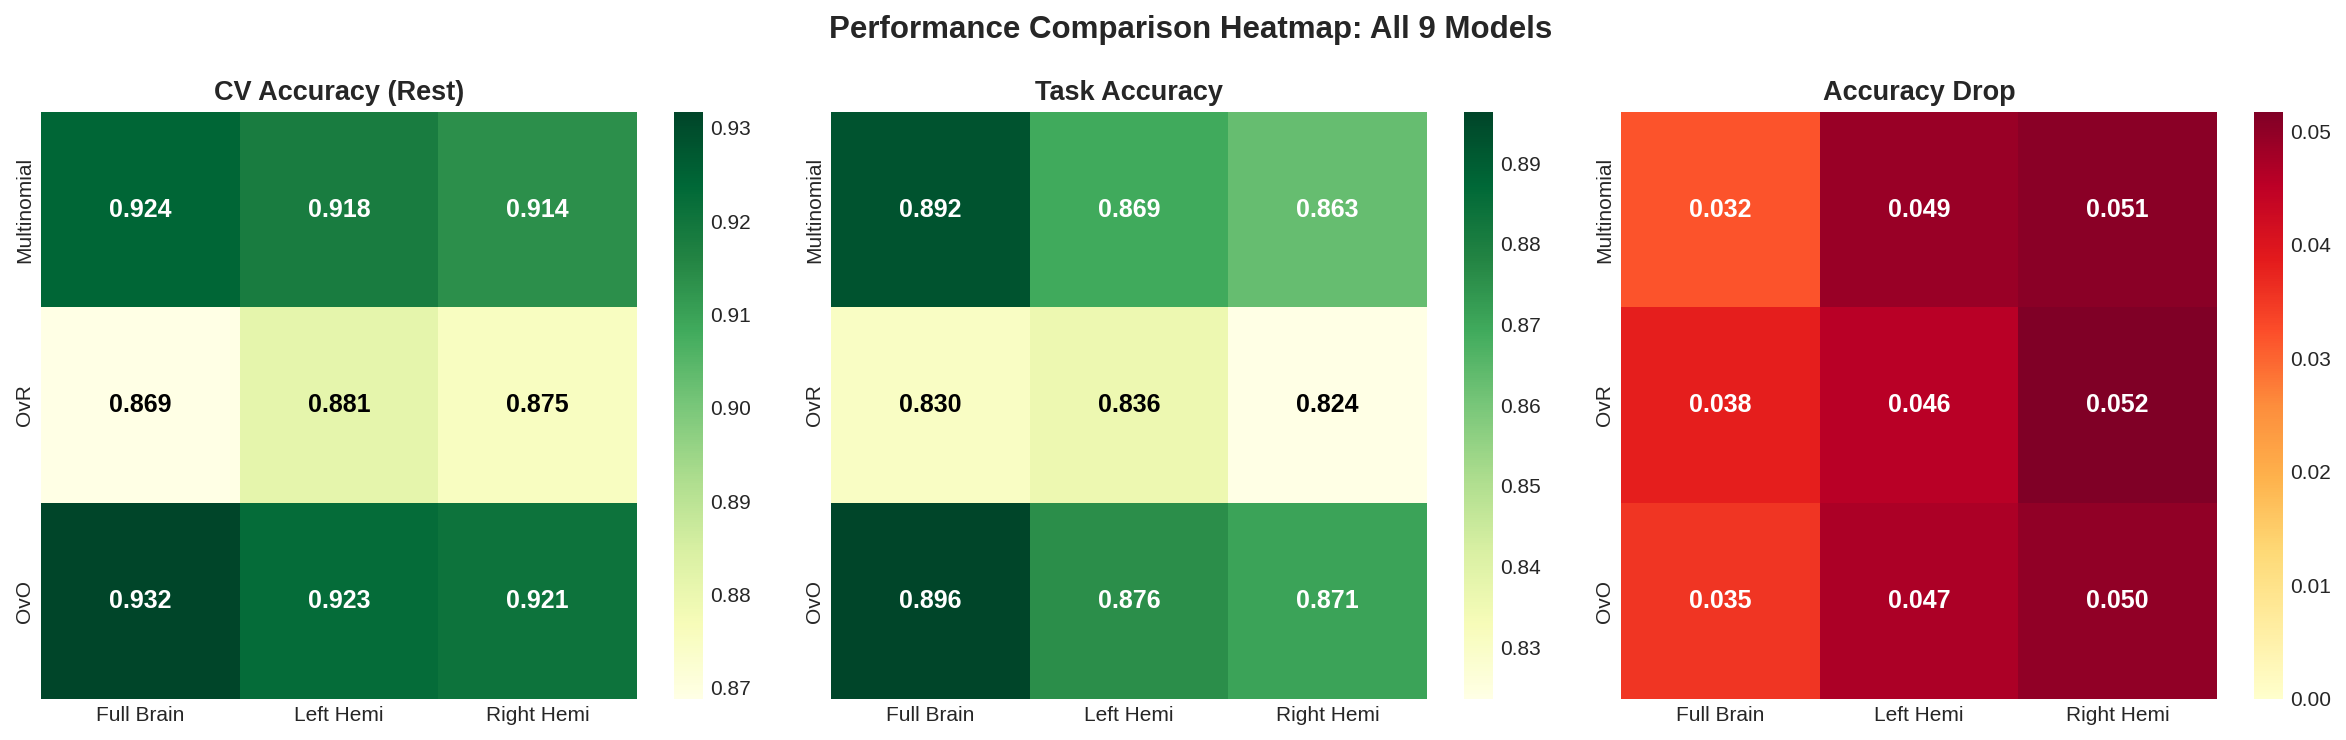

In [8]:
def plot_performance_heatmap(summary_df: pd.DataFrame, save_path: Optional[Path] = None):
    """
    Create heatmaps showing CV accuracy, Task accuracy, and Accuracy drop
    for all 9 models in a compact format.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics = ['cv_accuracy', 'task_accuracy', 'accuracy_drop']
    titles = ['CV Accuracy (Rest)', 'Task Accuracy', 'Accuracy Drop']
    cmaps = ['YlGn', 'YlGn', 'YlOrRd']
    
    for ax, metric, title, cmap in zip(axes, metrics, titles, cmaps):
        # Pivot for heatmap
        df_pivot = summary_df.pivot(index='strategy', columns='data_type', values=metric)
        df_pivot = df_pivot[['full', 'left', 'right']]  # Reorder
        df_pivot.index = ['Multinomial', 'OvR', 'OvO']
        df_pivot.columns = ['Full Brain', 'Left Hemi', 'Right Hemi']
        
        # Set vmin/vmax for better color scaling
        vmin = df_pivot.min().min() if metric != 'accuracy_drop' else 0
        vmax = df_pivot.max().max()
        
        # Create heatmap without annotations first
        sns.heatmap(df_pivot, annot=False, cmap=cmap,
                   ax=ax, cbar=True, vmin=vmin, vmax=vmax)
        
        # Add annotations with automatic contrast (white on dark, black on light)
        # Calculate the midpoint for determining text color
        mid_val = (vmin + vmax) / 2
        
        for i in range(len(df_pivot.index)):
            for j in range(len(df_pivot.columns)):
                val = df_pivot.iloc[i, j]
                # Choose text color based on cell value
                # For YlGn: high values are dark green, low values are light yellow
                # For YlOrRd: high values are dark red, low values are light yellow
                if metric == 'accuracy_drop':
                    # YlOrRd: dark at high values
                    text_color = 'white' if val > mid_val else 'black'
                else:
                    # YlGn: dark at high values
                    text_color = 'white' if val > mid_val else 'black'
                
                ax.text(j + 0.5, i + 0.5, f'{val:.3f}',
                       ha='center', va='center',
                       fontsize=12, fontweight='bold',
                       color=text_color)
        
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('')
        
        # Rotate x-axis labels for better readability
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    plt.suptitle('Performance Comparison Heatmap: All 9 Models', fontsize=15, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"✓ Saved: {save_path}")
    
    plt.show()

# Create heatmap
plot_performance_heatmap(summary_df, OUTPUT_DIR / "fig4_performance_heatmap.png")


In [9]:
# Statistical Summary and Key Findings

def generate_statistical_summary(summary_df: pd.DataFrame) -> str:
    """
    Generate a text summary of key statistical findings.
    """
    lines = []
    lines.append("="*80)
    lines.append("STATISTICAL SUMMARY: PERFORMANCE COMPARISON")
    lines.append("="*80)
    
    # Overall best model
    if 'cv_accuracy' in summary_df.columns:
        best_cv = summary_df.loc[summary_df['cv_accuracy'].idxmax()]
        lines.append(f"\n1. BEST CV ACCURACY:")
        lines.append(f"   Model: {best_cv['data_type'].upper()} - {best_cv['strategy'].upper()}")
        lines.append(f"   CV Accuracy: {best_cv['cv_accuracy']:.4f}")
    
    if 'task_accuracy' in summary_df.columns and summary_df['task_accuracy'].notna().any():
        best_task = summary_df.loc[summary_df['task_accuracy'].idxmax()]
        lines.append(f"\n2. BEST TASK ACCURACY:")
        lines.append(f"   Model: {best_task['data_type'].upper()} - {best_task['strategy'].upper()}")
        lines.append(f"   Task Accuracy: {best_task['task_accuracy']:.4f}")
    
    if 'accuracy_drop' in summary_df.columns and summary_df['accuracy_drop'].notna().any():
        # Smallest drop = best generalization
        best_gen = summary_df.loc[summary_df['accuracy_drop'].idxmin()]
        worst_gen = summary_df.loc[summary_df['accuracy_drop'].idxmax()]
        
        lines.append(f"\n3. BEST GENERALIZATION (smallest accuracy drop):")
        lines.append(f"   Model: {best_gen['data_type'].upper()} - {best_gen['strategy'].upper()}")
        lines.append(f"   Accuracy Drop: {best_gen['accuracy_drop']:.4f} ({best_gen['accuracy_drop_pct']:.1f}%)")
        
        lines.append(f"\n4. LARGEST REORGANIZATION (largest accuracy drop):")
        lines.append(f"   Model: {worst_gen['data_type'].upper()} - {worst_gen['strategy'].upper()}")
        lines.append(f"   Accuracy Drop: {worst_gen['accuracy_drop']:.4f} ({worst_gen['accuracy_drop_pct']:.1f}%)")
    
    # Strategy comparison
    lines.append(f"\n5. STRATEGY COMPARISON (averaged across data types):")
    strategy_means = summary_df.groupby('strategy')[['cv_accuracy', 'task_accuracy', 'accuracy_drop']].mean()
    for strategy in ['multinomial', 'ovr', 'ovo']:
        if strategy in strategy_means.index:
            row = strategy_means.loc[strategy]
            lines.append(f"   {strategy.upper():12} | CV: {row['cv_accuracy']:.4f} | Task: {row['task_accuracy']:.4f} | Drop: {row['accuracy_drop']:.4f}")
    
    # Data type comparison
    lines.append(f"\n6. DATA TYPE COMPARISON (averaged across strategies):")
    data_means = summary_df.groupby('data_type')[['cv_accuracy', 'task_accuracy', 'accuracy_drop']].mean()
    for data_type in ['full', 'left', 'right']:
        if data_type in data_means.index:
            row = data_means.loc[data_type]
            lines.append(f"   {data_type.upper():12} | CV: {row['cv_accuracy']:.4f} | Task: {row['task_accuracy']:.4f} | Drop: {row['accuracy_drop']:.4f}")
    
    # Improvement over chance
    lines.append(f"\n7. IMPROVEMENT OVER CHANCE:")
    for _, row in summary_df.iterrows():
        chance = 1 / row['n_regions']
        improvement = row['cv_accuracy'] / chance
        lines.append(f"   {row['data_type'].upper():6} {row['strategy'].upper():12} | {improvement:.1f}x chance ({chance:.4f})")
    
    lines.append("\n" + "="*80)
    
    return "\n".join(lines)

# Generate and print summary
summary_text = generate_statistical_summary(summary_df)
print(summary_text)

# Save to file
with open(OUTPUT_DIR / "statistical_summary.txt", 'w') as f:
    f.write(summary_text)
print(f"\n✓ Saved: {OUTPUT_DIR / 'statistical_summary.txt'}")

STATISTICAL SUMMARY: PERFORMANCE COMPARISON

1. BEST CV ACCURACY:
   Model: FULL - OVR
   CV Accuracy: 0.9317

2. BEST TASK ACCURACY:
   Model: FULL - OVR
   Task Accuracy: 0.8963

3. BEST GENERALIZATION (smallest accuracy drop):
   Model: FULL - MULTINOMIAL
   Accuracy Drop: 0.0317 (3.4%)

4. LARGEST REORGANIZATION (largest accuracy drop):
   Model: RIGHT - OVO
   Accuracy Drop: 0.0517 (5.9%)

5. STRATEGY COMPARISON (averaged across data types):
   MULTINOMIAL  | CV: 0.9186 | Task: 0.8749 | Drop: 0.0437
   OVR          | CV: 0.9251 | Task: 0.8810 | Drop: 0.0440
   OVO          | CV: 0.8752 | Task: 0.8300 | Drop: 0.0452

6. DATA TYPE COMPARISON (averaged across strategies):
   FULL         | CV: 0.9082 | Task: 0.8731 | Drop: 0.0351
   LEFT         | CV: 0.9074 | Task: 0.8603 | Drop: 0.0471
   RIGHT        | CV: 0.9032 | Task: 0.8526 | Drop: 0.0507

7. IMPROVEMENT OVER CHANCE:
   FULL   MULTINOMIAL  | 214.4x chance (0.0043)
   FULL   OVR          | 216.2x chance (0.0043)
   FULL   OVO  

In [10]:
# Detailed Comparison Tables for Thesis
def create_thesis_tables(summary_df: pd.DataFrame, output_dir: Path):
    """
    Create publication-ready tables for the thesis.
    """
    
    # Table 1: Main Results Table
    table1 = summary_df[['data_type', 'strategy', 'n_regions', 'cv_accuracy', 
                         'cv_balanced_accuracy', 'task_accuracy', 'accuracy_drop']].copy()
    table1.columns = ['Data Type', 'Strategy', 'Regions', 'CV Accuracy', 
                      'CV Balanced Acc', 'Task Accuracy', 'Accuracy Drop']
    table1['Data Type'] = table1['Data Type'].str.capitalize()
    table1['Strategy'] = table1['Strategy'].str.upper()
    
    # Round for display
    for col in ['CV Accuracy', 'CV Balanced Acc', 'Task Accuracy', 'Accuracy Drop']:
        table1[col] = table1[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
    
    print("\n" + "="*80)
    print("TABLE 1: Classification Performance Summary")
    print("="*80)
    print(table1.to_string(index=False))
    table1.to_csv(output_dir / "table1_performance_summary.csv", index=False)
    
    # Table 2: Strategy Comparison
    table2 = summary_df.groupby('strategy').agg({
        'cv_accuracy': ['mean', 'std'],
        'task_accuracy': ['mean', 'std'],
        'accuracy_drop': ['mean', 'std']
    }).round(4)
    table2.columns = ['_'.join(col).strip() for col in table2.columns.values]
    table2 = table2.reset_index()
    table2['strategy'] = table2['strategy'].str.upper()
    
    print("\n" + "="*80)
    print("TABLE 2: Strategy Comparison (Mean ± Std across data types)")
    print("="*80)
    print(table2.to_string(index=False))
    table2.to_csv(output_dir / "table2_strategy_comparison.csv", index=False)
    
    # Table 3: Data Type Comparison
    table3 = summary_df.groupby('data_type').agg({
        'cv_accuracy': ['mean', 'std'],
        'task_accuracy': ['mean', 'std'],
        'accuracy_drop': ['mean', 'std']
    }).round(4)
    table3.columns = ['_'.join(col).strip() for col in table3.columns.values]
    table3 = table3.reset_index()
    table3['data_type'] = table3['data_type'].str.capitalize()
    
    print("\n" + "="*80)
    print("TABLE 3: Data Type Comparison (Mean ± Std across strategies)")
    print("="*80)
    print(table3.to_string(index=False))
    table3.to_csv(output_dir / "table3_datatype_comparison.csv", index=False)
    
    print(f"\n✓ Saved all tables to {output_dir}")


# Create thesis tables
create_thesis_tables(summary_df, OUTPUT_DIR)


TABLE 1: Classification Performance Summary
Data Type    Strategy  Regions CV Accuracy CV Balanced Acc Task Accuracy Accuracy Drop
     Full MULTINOMIAL      232      0.9241          0.9241        0.8924        0.0317
     Full         OVR      232      0.9317          0.9317        0.8963        0.0354
     Full         OVO      232      0.8688          0.8688        0.8305        0.0383
     Left MULTINOMIAL      116      0.9182          0.9182        0.8693        0.0489
     Left         OVR      116      0.9226          0.9226        0.8757        0.0470
     Left         OVO      116      0.8814          0.8814        0.8359        0.0456
    Right MULTINOMIAL      116      0.9136          0.9136        0.8631        0.0505
    Right         OVR      116      0.9208          0.9208        0.8710        0.0498
    Right         OVO      116      0.8753          0.8753        0.8236        0.0517

TABLE 2: Strategy Comparison (Mean ± Std across data types)
   strategy  cv_accuracy

✓ Saved: reports/performance_comparison/fig5_publication_combined.png


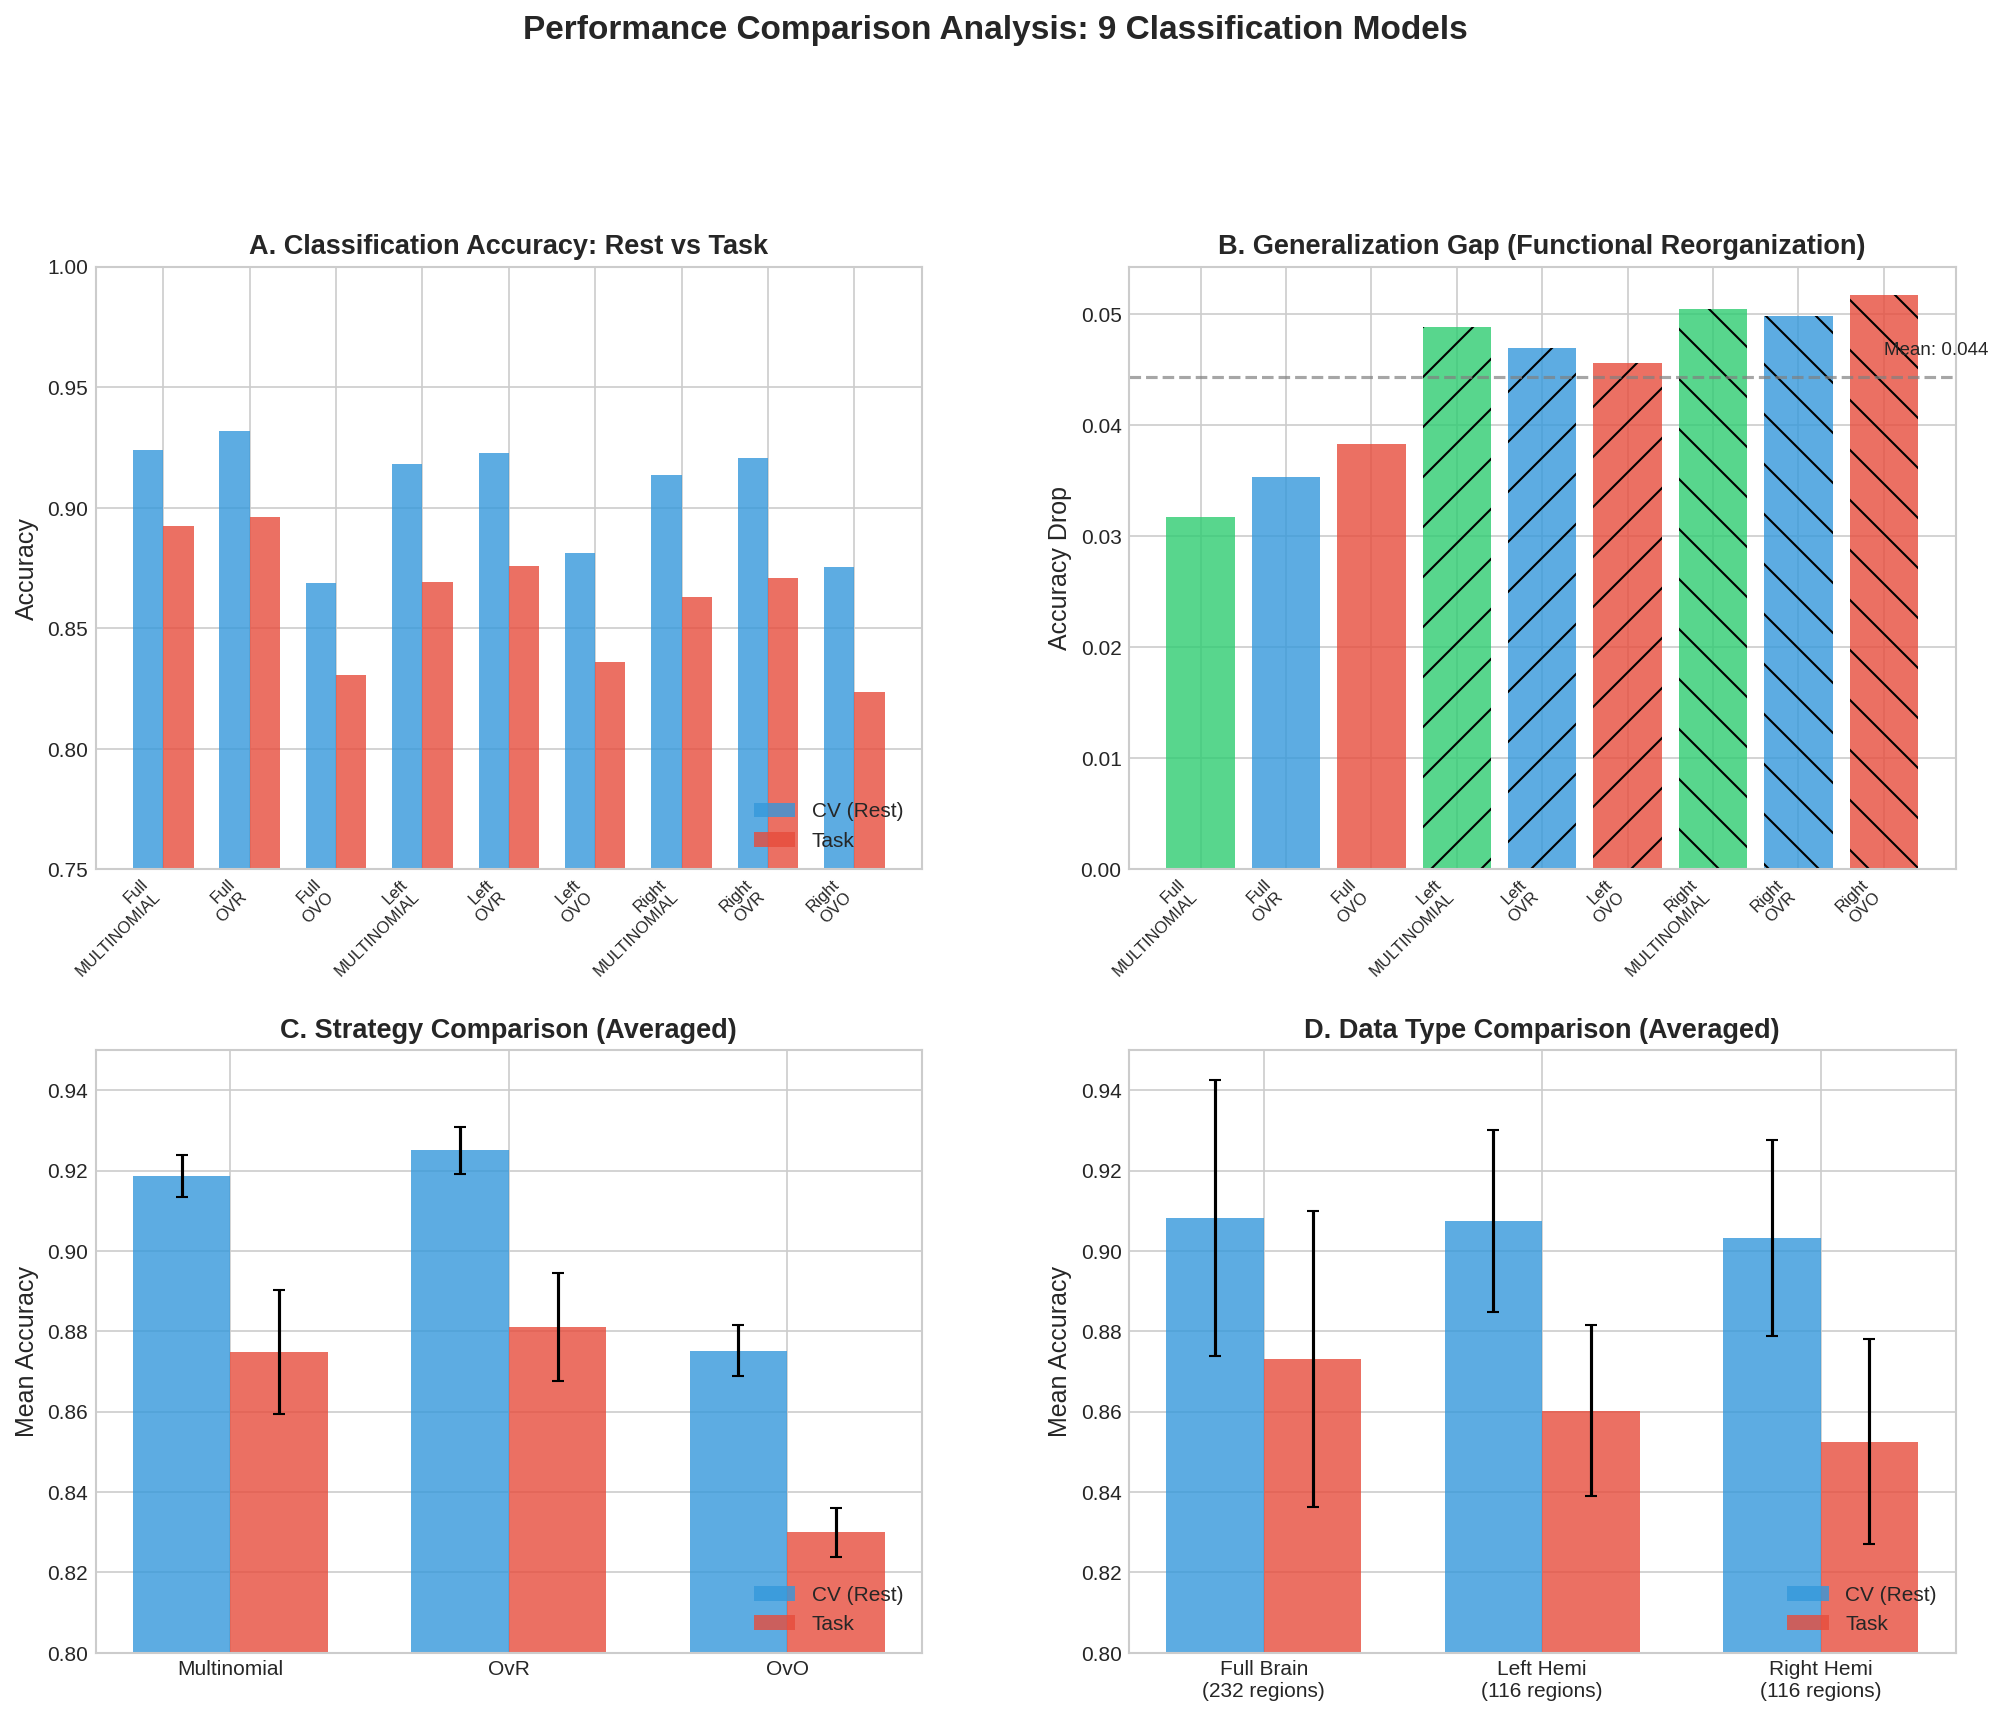

In [11]:
def create_publication_figure(summary_df: pd.DataFrame, save_path: Optional[Path] = None):
    """
    Create a single, comprehensive publication-ready figure combining key comparisons.
    """
    fig = plt.figure(figsize=(16, 12))
    
    # Create grid
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
    
    # --- Panel A: CV vs Task Accuracy (all models) ---
    ax1 = fig.add_subplot(gs[0, 0])
    
    x_labels = [f"{row['data_type'].capitalize()}\n{row['strategy'].upper()}" 
                for _, row in summary_df.iterrows()]
    x = np.arange(len(x_labels))
    width = 0.35
    
    ax1.bar(x - width/2, summary_df['cv_accuracy'], width, 
            label='CV (Rest)', color='#3498db', alpha=0.8)
    ax1.bar(x + width/2, summary_df['task_accuracy'], width,
            label='Task', color='#e74c3c', alpha=0.8)
    
    ax1.set_ylabel('Accuracy')
    ax1.set_title('A. Classification Accuracy: Rest vs Task', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax1.legend(loc='lower right')
    ax1.set_ylim(0.75, 1.0)
    
    # --- Panel B: Accuracy Drop ---
    ax2 = fig.add_subplot(gs[0, 1])
    
    colors = [COLORS[row['strategy']] for _, row in summary_df.iterrows()]
    bars = ax2.bar(x, summary_df['accuracy_drop'], color=colors, alpha=0.8)
    
    # Add pattern for data types
    patterns = {'full': '', 'left': '/', 'right': '\\'}
    for bar, (_, row) in zip(bars, summary_df.iterrows()):
        bar.set_hatch(patterns[row['data_type']])
    
    ax2.set_ylabel('Accuracy Drop')
    ax2.set_title('B. Generalization Gap (Functional Reorganization)', fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax2.axhline(y=summary_df['accuracy_drop'].mean(), color='gray', linestyle='--', alpha=0.7)
    ax2.text(len(x)-1, summary_df['accuracy_drop'].mean() + 0.002, 
             f"Mean: {summary_df['accuracy_drop'].mean():.3f}", fontsize=9)
    
    # --- Panel C: Strategy Comparison ---
    ax3 = fig.add_subplot(gs[1, 0])
    
    strategy_means = summary_df.groupby('strategy')[['cv_accuracy', 'task_accuracy']].mean()
    strategy_means = strategy_means.loc[['multinomial', 'ovr', 'ovo']]
    
    x_strat = np.arange(3)
    ax3.bar(x_strat - width/2, strategy_means['cv_accuracy'], width,
            label='CV (Rest)', color='#3498db', alpha=0.8)
    ax3.bar(x_strat + width/2, strategy_means['task_accuracy'], width,
            label='Task', color='#e74c3c', alpha=0.8)
    
    ax3.set_ylabel('Mean Accuracy')
    ax3.set_title('C. Strategy Comparison (Averaged)', fontweight='bold')
    ax3.set_xticks(x_strat)
    ax3.set_xticklabels(['Multinomial', 'OvR', 'OvO'])
    ax3.legend(loc='lower right')
    ax3.set_ylim(0.8, 0.95)
    
    # Add error bars
    strategy_std = summary_df.groupby('strategy')[['cv_accuracy', 'task_accuracy']].std()
    strategy_std = strategy_std.loc[['multinomial', 'ovr', 'ovo']]
    ax3.errorbar(x_strat - width/2, strategy_means['cv_accuracy'], 
                 yerr=strategy_std['cv_accuracy'], fmt='none', color='black', capsize=3)
    ax3.errorbar(x_strat + width/2, strategy_means['task_accuracy'],
                 yerr=strategy_std['task_accuracy'], fmt='none', color='black', capsize=3)
    
    # --- Panel D: Data Type Comparison ---
    ax4 = fig.add_subplot(gs[1, 1])
    
    data_means = summary_df.groupby('data_type')[['cv_accuracy', 'task_accuracy']].mean()
    data_means = data_means.loc[['full', 'left', 'right']]
    
    x_data = np.arange(3)
    ax4.bar(x_data - width/2, data_means['cv_accuracy'], width,
            label='CV (Rest)', color='#3498db', alpha=0.8)
    ax4.bar(x_data + width/2, data_means['task_accuracy'], width,
            label='Task', color='#e74c3c', alpha=0.8)
    
    ax4.set_ylabel('Mean Accuracy')
    ax4.set_title('D. Data Type Comparison (Averaged)', fontweight='bold')
    ax4.set_xticks(x_data)
    ax4.set_xticklabels(['Full Brain\n(232 regions)', 'Left Hemi\n(116 regions)', 'Right Hemi\n(116 regions)'])
    ax4.legend(loc='lower right')
    ax4.set_ylim(0.8, 0.95)
    
    # Add error bars
    data_std = summary_df.groupby('data_type')[['cv_accuracy', 'task_accuracy']].std()
    data_std = data_std.loc[['full', 'left', 'right']]
    ax4.errorbar(x_data - width/2, data_means['cv_accuracy'],
                 yerr=data_std['cv_accuracy'], fmt='none', color='black', capsize=3)
    ax4.errorbar(x_data + width/2, data_means['task_accuracy'],
                 yerr=data_std['task_accuracy'], fmt='none', color='black', capsize=3)
    
    plt.suptitle('Performance Comparison Analysis: 9 Classification Models', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    plt.show()

# Create publication figure
create_publication_figure(summary_df, OUTPUT_DIR / "fig5_publication_combined.png")

In [12]:
def generate_thesis_findings(summary_df: pd.DataFrame) -> str:
    """
    Generate key findings formatted for thesis Results section.
    """
    lines = []
    lines.append("="*80)
    lines.append("KEY FINDINGS FOR THESIS")
    lines.append("="*80)
    
    # Finding 1: Overall model performance
    mean_cv = summary_df['cv_accuracy'].mean()
    mean_task = summary_df['task_accuracy'].mean()
    mean_drop = summary_df['accuracy_drop'].mean()
    
    lines.append("\n## Finding 1: High Classification Accuracy")
    lines.append(f"All nine models achieved high classification accuracy, with mean")
    lines.append(f"cross-validation accuracy of {mean_cv:.1%} on resting-state data")
    lines.append(f"and {mean_task:.1%} on task data. This demonstrates that")
    lines.append(f"functional connectivity patterns reliably distinguish brain regions.")
    
    # Finding 2: Best performing strategy
    best_cv_strategy = summary_df.groupby('strategy')['cv_accuracy'].mean().idxmax()
    best_task_strategy = summary_df.groupby('strategy')['task_accuracy'].mean().idxmax()
    best_gen_strategy = summary_df.groupby('strategy')['accuracy_drop'].mean().idxmin()
    
    lines.append("\n## Finding 2: Strategy Comparison")
    lines.append(f"Comparing classification strategies:")
    lines.append(f"  - Best CV accuracy: {best_cv_strategy.upper()}")
    lines.append(f"  - Best task accuracy: {best_task_strategy.upper()}")
    lines.append(f"  - Best generalization (smallest drop): {best_gen_strategy.upper()}")
    
    # Finding 3: Hemisphere comparison
    hemi_means = summary_df.groupby('data_type')['accuracy_drop'].mean()
    
    lines.append("\n## Finding 3: Hemisphere-Specific Reorganization")
    if 'left' in hemi_means.index and 'right' in hemi_means.index:
        left_drop = hemi_means['left']
        right_drop = hemi_means['right']
        if left_drop > right_drop:
            lines.append(f"Left hemisphere showed greater functional reorganization")
            lines.append(f"(accuracy drop: {left_drop:.1%}) compared to right hemisphere")
            lines.append(f"({right_drop:.1%}), consistent with the language/cognitive")
            lines.append(f"demands of the Gender Stroop task.")
        else:
            lines.append(f"Right hemisphere showed greater functional reorganization")
            lines.append(f"(accuracy drop: {right_drop:.1%}) compared to left hemisphere")
            lines.append(f"({left_drop:.1%}).")
    
    # Finding 4: Rest-to-task generalization gap
    lines.append("\n## Finding 4: Functional Reorganization Quantified")
    lines.append(f"The mean accuracy drop from rest to task was {mean_drop:.1%},")
    lines.append(f"representing the magnitude of task-induced functional reorganization.")
    lines.append(f"This gap varied across models, with the largest drop of")
    lines.append(f"{summary_df['accuracy_drop'].max():.1%} and smallest of")
    lines.append(f"{summary_df['accuracy_drop'].min():.1%}.")
    
    lines.append("\n" + "="*80)
    
    return "\n".join(lines)

# Generate findings
findings = generate_thesis_findings(summary_df)
print(findings)

# Save to file
with open(OUTPUT_DIR / "thesis_key_findings.txt", 'w') as f:
    f.write(findings)
print(f"\n✓ Saved: {OUTPUT_DIR / 'thesis_key_findings.txt'}")

KEY FINDINGS FOR THESIS

## Finding 1: High Classification Accuracy
All nine models achieved high classification accuracy, with mean
cross-validation accuracy of 90.6% on resting-state data
and 86.2% on task data. This demonstrates that
functional connectivity patterns reliably distinguish brain regions.

## Finding 2: Strategy Comparison
Comparing classification strategies:
  - Best CV accuracy: OVR
  - Best task accuracy: OVR
  - Best generalization (smallest drop): MULTINOMIAL

## Finding 3: Hemisphere-Specific Reorganization
Right hemisphere showed greater functional reorganization
(accuracy drop: 5.1%) compared to left hemisphere
(4.7%).

## Finding 4: Functional Reorganization Quantified
The mean accuracy drop from rest to task was 4.4%,
representing the magnitude of task-induced functional reorganization.
This gap varied across models, with the largest drop of
5.2% and smallest of
3.2%.


✓ Saved: reports/performance_comparison/thesis_key_findings.txt


In [13]:
# Final Summary and Next Steps
print("="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nAll outputs saved to: {OUTPUT_DIR}")
print("\nGenerated files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(f"  • {f.name}")

print("\n" + "-"*80)
print("NEXT STEPS FOR YOUR THESIS:")
print("-"*80)
print("""
1. REGION-LEVEL ANALYSIS (Analysis 4)
   - Rank individual regions by misclassification rate
   - Identify which brain areas show greatest reorganization

2. NETWORK-LEVEL ANALYSIS (Analysis 5)  
   - Aggregate results by Schaefer 17 networks
   - Compare network-level reorganization patterns

3. CONFUSION MATRIX ANALYSIS (Analysis 3)
   - Analyze which regions get confused with which
   - Examine bilateral hemisphere confusion patterns

4. HEMISPHERE ASYMMETRY (Analysis 6)
   - Deep dive into left vs right differences
   - Connect to Gender Stroop task lateralization

Run the next notebook: 02_region_level_analysis.py
""")

ANALYSIS COMPLETE

All outputs saved to: reports/performance_comparison

Generated files:
  • fig1_strategy_comparison.png
  • fig2_data_type_comparison.png
  • fig3_generalization_gap.png
  • fig4_performance_heatmap.png
  • fig5_publication_combined.png
  • performance_summary.csv
  • statistical_summary.txt
  • table1_performance_summary.csv
  • table2_strategy_comparison.csv
  • table3_datatype_comparison.csv
  • thesis_key_findings.txt

--------------------------------------------------------------------------------
NEXT STEPS FOR YOUR THESIS:
--------------------------------------------------------------------------------

1. REGION-LEVEL ANALYSIS (Analysis 4)
   - Rank individual regions by misclassification rate
   - Identify which brain areas show greatest reorganization

2. NETWORK-LEVEL ANALYSIS (Analysis 5)  
   - Aggregate results by Schaefer 17 networks
   - Compare network-level reorganization patterns

3. CONFUSION MATRIX ANALYSIS (Analysis 3)
   - Analyze which regions